# Distribution Representations: Density, CDF, Quantile, and Quantile Density

This notebook explores different ways to represent a probability distribution and how they relate to each other both theoretically and empirically.

We focus on four key objects:

* **Density function (PDF)**
* **Cumulative distribution function (CDF)**
* **Quantile function**
* **Quantile density function (QDF)**

The goal is to understand how these representations encode the same distribution while exhibiting very different numerical and geometric behaviors.

---

# 1. Theoretical Framework

## 1.1 Distribution as a Measure

A probability distribution can be formally defined as a measure $ \mu $ on $ \mathbb{R} $. From this single object, all representations follow.

---

## 1.2 Cumulative Distribution Function (CDF)

The CDF is defined as:

$$
F(x) = \mu((-\infty, x])
$$

It maps **values → probabilities**.

* Monotone increasing
* Right-continuous
* Stable representation

---

## 1.3 Probability Density Function (PDF)

If the distribution is absolutely continuous:

$$
f(x) = \frac{dF(x)}{dx}
$$

It represents how probability mass is locally distributed.

* Local object
* Sensitive to noise
* Requires smoothness assumptions

---

## 1.4 Quantile Function

The quantile function is the generalized inverse of the CDF:

$$
Q(u) = \inf { x \in \mathbb{R} : F(x) \ge u }, \quad u \in (0,1)
$$

It maps **probabilities → values**.

* Always exists (generalized inverse)
* Monotone increasing
* Natural for simulation and geometry

---

## 1.5 Quantile Density Function (QDF)

Defined as the derivative of the quantile function:

$$
q(u) = Q'(u)
$$

Using the chain rule:

$$
q(u) = \frac{1}{f(Q(u))}
$$

This is a key identity.

---

# 2. Interpretation of the QDF

The quantile density measures:

> "How much the value must change to increase probability slightly"

---

### Key intuition:

* If ( f(x) ) is **large** → many points nearby
  → ( q(u) ) is **small**

* If ( f(x) ) is **small** → sparse region
  → ( q(u) ) is **large**

---

### Critical implication:

[
q(u) \to \infty \quad \text{when} \quad f(Q(u)) \to 0
]

This happens in:

* Tails of distributions
* Low-density regions
* Poor KDE estimates

---

# 3. Empirical Estimation in the Code

The code constructs empirical counterparts of these objects.

---

## 3.1 Density (KDE)

```python
kde = stats.gaussian_kde(data)
```

* Smooth estimate of ( f(x) )
* Sensitive to bandwidth and outliers

---

## 3.2 Quantile Function

```python
q = np.quantile(data, u)
```

* Empirical quantile
* Robust and well-defined

---

## 3.3 Quantile Density (Numerical)

```python
dq = np.gradient(q, u)
```

* Finite-difference approximation of ( Q'(u) )
* Highly sensitive to noise

---

# 4. Observations from the Plots

## 4.1 Normal Distribution

* Smooth density
* Smooth quantile
* QDF relatively stable

---

## 4.2 Heavy-Tailed Distributions (Student-t, Cauchy)

* Density becomes very small in tails
* Quantile grows rapidly
* QDF **explodes near ( u \to 0,1 )**

---

## 4.3 KDE with Outliers

* Outliers create sparse regions
* KDE assigns very low density in tails
* QDF becomes large and unstable

---

## 4.4 Numerical Instability

The QDF plot reveals:

* Noise amplification in tails
* Sensitivity to sampling variability
* Instability from finite differences

---

# 5. Key Insight

The four representations behave very differently:

| Representation | Stability | Local/Global |
| -------------- | --------- | ------------ |
| CDF            | High      | Global       |
| PDF            | Medium    | Local        |
| Quantile       | Medium    | Global       |
| QDF            | Low       | Highly Local |

---

## Fundamental takeaway:

> The quantile density function is the most sensitive representation of a distribution.

---

# 6. Connection to Tail Behavior

* Light tails → density decays quickly → moderate QDF growth
* Heavy tails → density extremely small → large QDF

Thus:

> Tail behavior is directly reflected in the growth of ( q(u) )

---

# 7. Implications for KDE and Modeling

This experiment highlights an important issue:

* KDE operates in **density space**
* Quantile-based methods operate in **inverse-density space**

Therefore:

* Small errors in density estimation
* → Large errors in quantiles
* → Extreme instability in QDF

---

# 8. Conceptual Unification

All representations come from the same underlying object:

[
\text{Measure} ;; \longrightarrow ;;
\begin{cases}
F(x) \
f(x) \
Q(u) \
q(u)
\end{cases}
]

They are equivalent in theory, but not in practice.

---

# 9. Final Perspective

This notebook demonstrates:

* Why quantile representations are powerful
* Why they become unstable in tails
* Why density estimation errors propagate nonlinearly

---

## Core idea to retain:

> Quantile instability is fundamentally a **low-density phenomenon**, not just an outlier effect.

---


In [53]:
import numpy as np
import pandas as pd
import plotly.express as px
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(42)
n = 5000

# -----------------------------
# I) Normal (symmetric, light tails)
# -----------------------------
normal = np.random.normal(0, 1, n)

# -----------------------------
# II) Student-t (heavy tails, symmetric)
# -----------------------------
student_t = stats.t(df=2).rvs(size=n)

# -----------------------------
# III) Left-skewed
# Negative skew → reflect exponential
# -----------------------------
left_skewed = -np.random.exponential(scale=1, size=n)

# -----------------------------
# IV) Right-skewed
# Positive skew → exponential
# -----------------------------
right_skewed = np.random.exponential(scale=1, size=n)

datasets = {
    "Normal": normal,
    "Student-t": student_t,
    "Left-skewed": left_skewed,
    "Right-skewed": right_skewed
}

# -----------------------------
# Density (KDE)
# -----------------------------
density_df = []
x_grid = np.linspace(-10, 10, 500)

for name, data in datasets.items():
    kde = stats.gaussian_kde(data)
    y = kde(x_grid)
    
    density_df.append(pd.DataFrame({
        "x": x_grid,
        "density": y,
        "distribution": name
    }))

density_df = pd.concat(density_df)

fig_density = px.line(
    density_df,
    x="x",
    y="density",
    color="distribution",
    title="KDE Densities"
)
fig_density.show()


# -----------------------------
# Quantile function
# Avoid exact 0 and 1 (important!)
# -----------------------------
u = np.linspace(0.000, 1, 500)

quantile_df = []
qdf_df = []

for name, data in datasets.items():
    q = np.quantile(data, u)
    
    # Numerical derivative (QDF)
    dq = np.gradient(q, u)
    
    quantile_df.append(pd.DataFrame({
        "u": u,
        "quantile": q,
        "distribution": name
    }))
    
    qdf_df.append(pd.DataFrame({
        "u": u,
        "qdf": dq,
        "distribution": name
    }))

quantile_df = pd.concat(quantile_df)
qdf_df = pd.concat(qdf_df)


# -----------------------------
# Plot quantile functions
# -----------------------------
fig_quantile = px.line(
    quantile_df,
    x="u",
    y="quantile",
    color="distribution",
    title="Empirical Quantile Functions"
)
fig_quantile.show()


# -----------------------------
# Plot quantile density (QDF)
# -----------------------------
fig_qdf = px.line(
    qdf_df,
    x="u",
    y="qdf",
    color="distribution",
    title="Quantile Density Function q(u) = Q'(u)"
)

# Log scale to highlight tail behavior
# fig_qdf.update_yaxes(type="log")
fig_qdf.update_xaxes(range=[-0.05, 1.05])

fig_qdf.show()

/var/folders/t3/pppk4b013151kb4wpjbj3hvh0000gn/T/ipykernel_3057/2464535466.py:2: RuntimeWarning:

divide by zero encountered in log



Text(0.5, 1.0, 'Applying -log to [0,1]')

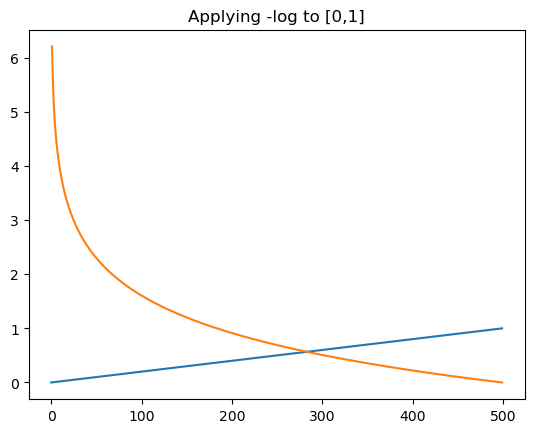

In [54]:
pd.Series(np.linspace(0,1, 500)).plot()
pd.Series(-np.log(np.linspace(0,1, 500))).plot()

plt.title("Applying -log to [0,1]")

In [55]:
log_qdf_df = qdf_df.copy()

for col in log_qdf_df.select_dtypes(float).columns:
    log_qdf_df[col] = np.log(log_qdf_df[col])

px.line(log_qdf_df, color="distribution", title="-log(q(p))")

/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning:

divide by zero encountered in log

